# 数据可视化汇总

本笔记本整合了所有可视化内容：
1. 负荷数据可视化
2. 目标负荷数据可视化
3. 特征相关性分析

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('default')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

---
## 一、负荷数据可视化

In [2]:
# 加载负荷数据
df_load = pd.read_csv('data/负荷_预处理后.csv', parse_dates=['timestamp'])
df_load.set_index('timestamp', inplace=True)

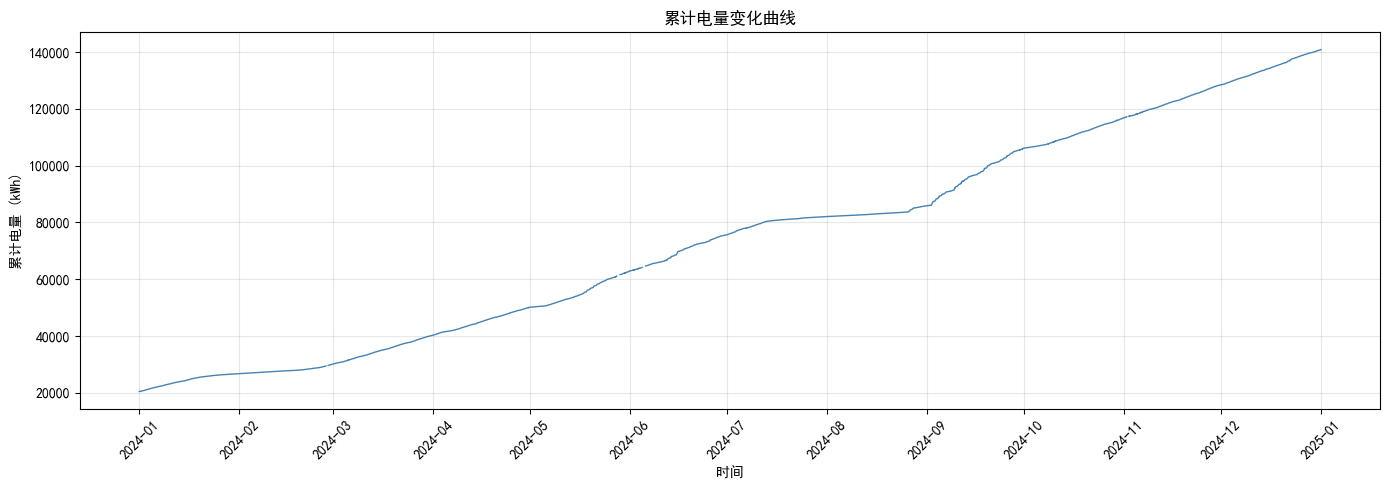

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_load.index, df_load['load_kwh'], color='steelblue', linewidth=1)
ax.set_xlabel('时间')
ax.set_ylabel('累计电量 (kWh)')
ax.set_title('累计电量变化曲线')
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

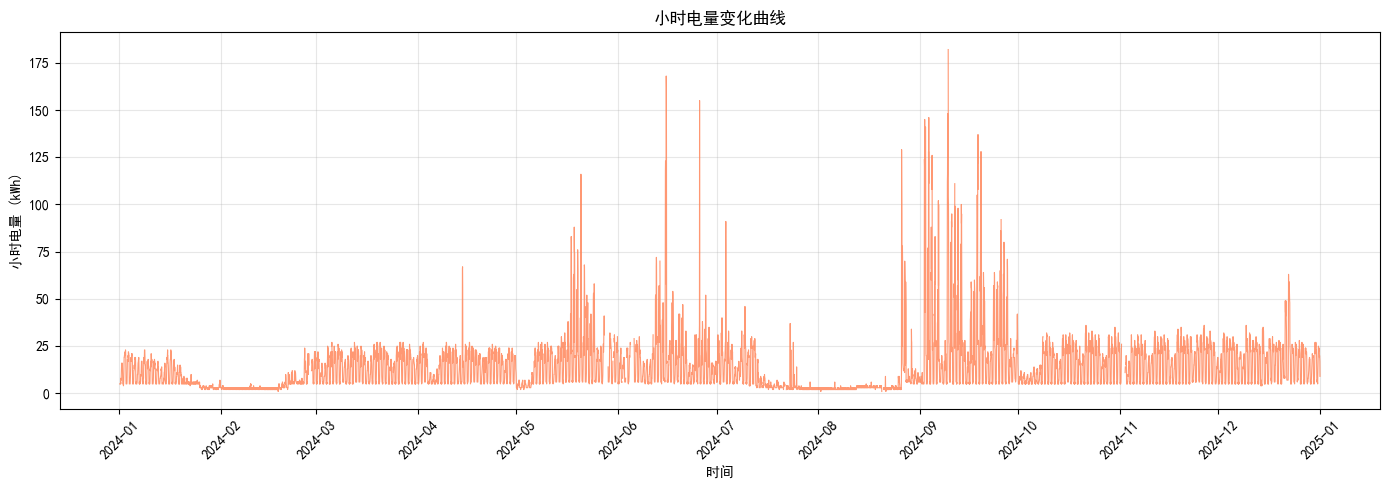

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_load.index, df_load['hourly_kwh'], color='coral', linewidth=0.8, alpha=0.8)
ax.set_xlabel('时间')
ax.set_ylabel('小时电量 (kWh)')
ax.set_title('小时电量变化曲线')
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

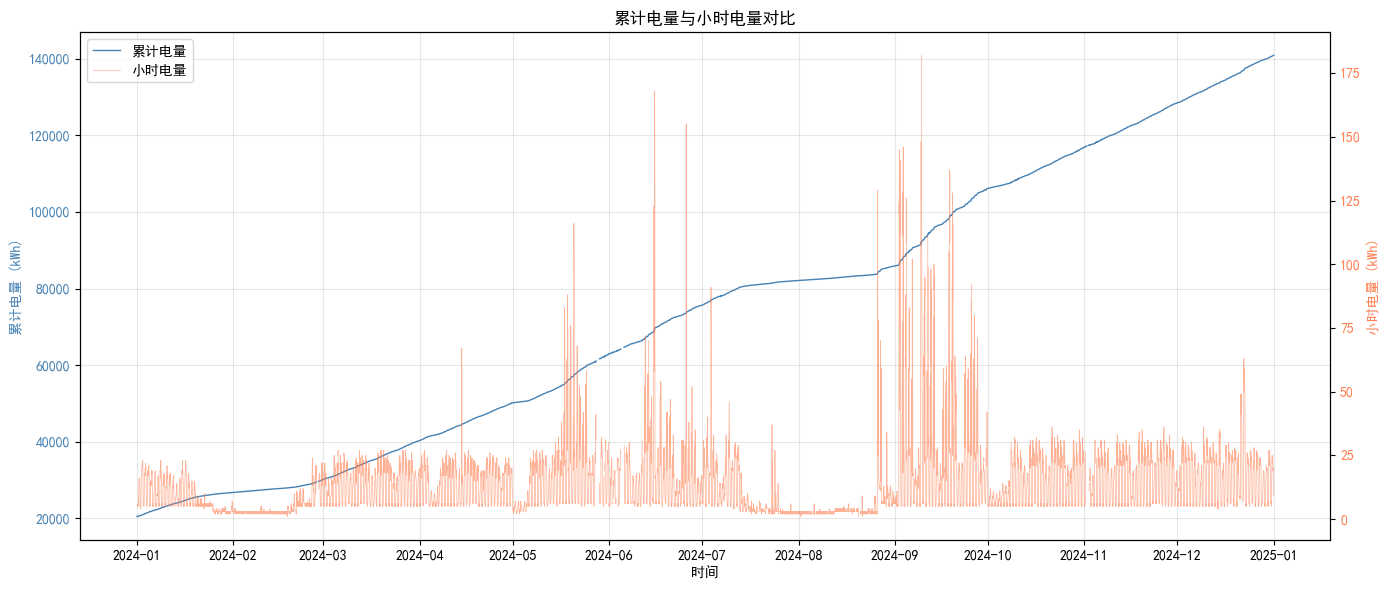

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# 累计电量（左Y轴）
color1 = 'steelblue'
ax1.plot(df_load.index, df_load['load_kwh'], color=color1, linewidth=1, label='累计电量')
ax1.set_xlabel('时间')
ax1.set_ylabel('累计电量 (kWh)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# 小时电量（右Y轴）
ax2 = ax1.twinx()
color2 = 'coral'
ax2.plot(df_load.index, df_load['hourly_kwh'], color=color2, linewidth=0.5, alpha=0.6, label='小时电量')
ax2.set_ylabel('小时电量 (kWh)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('累计电量与小时电量对比')
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

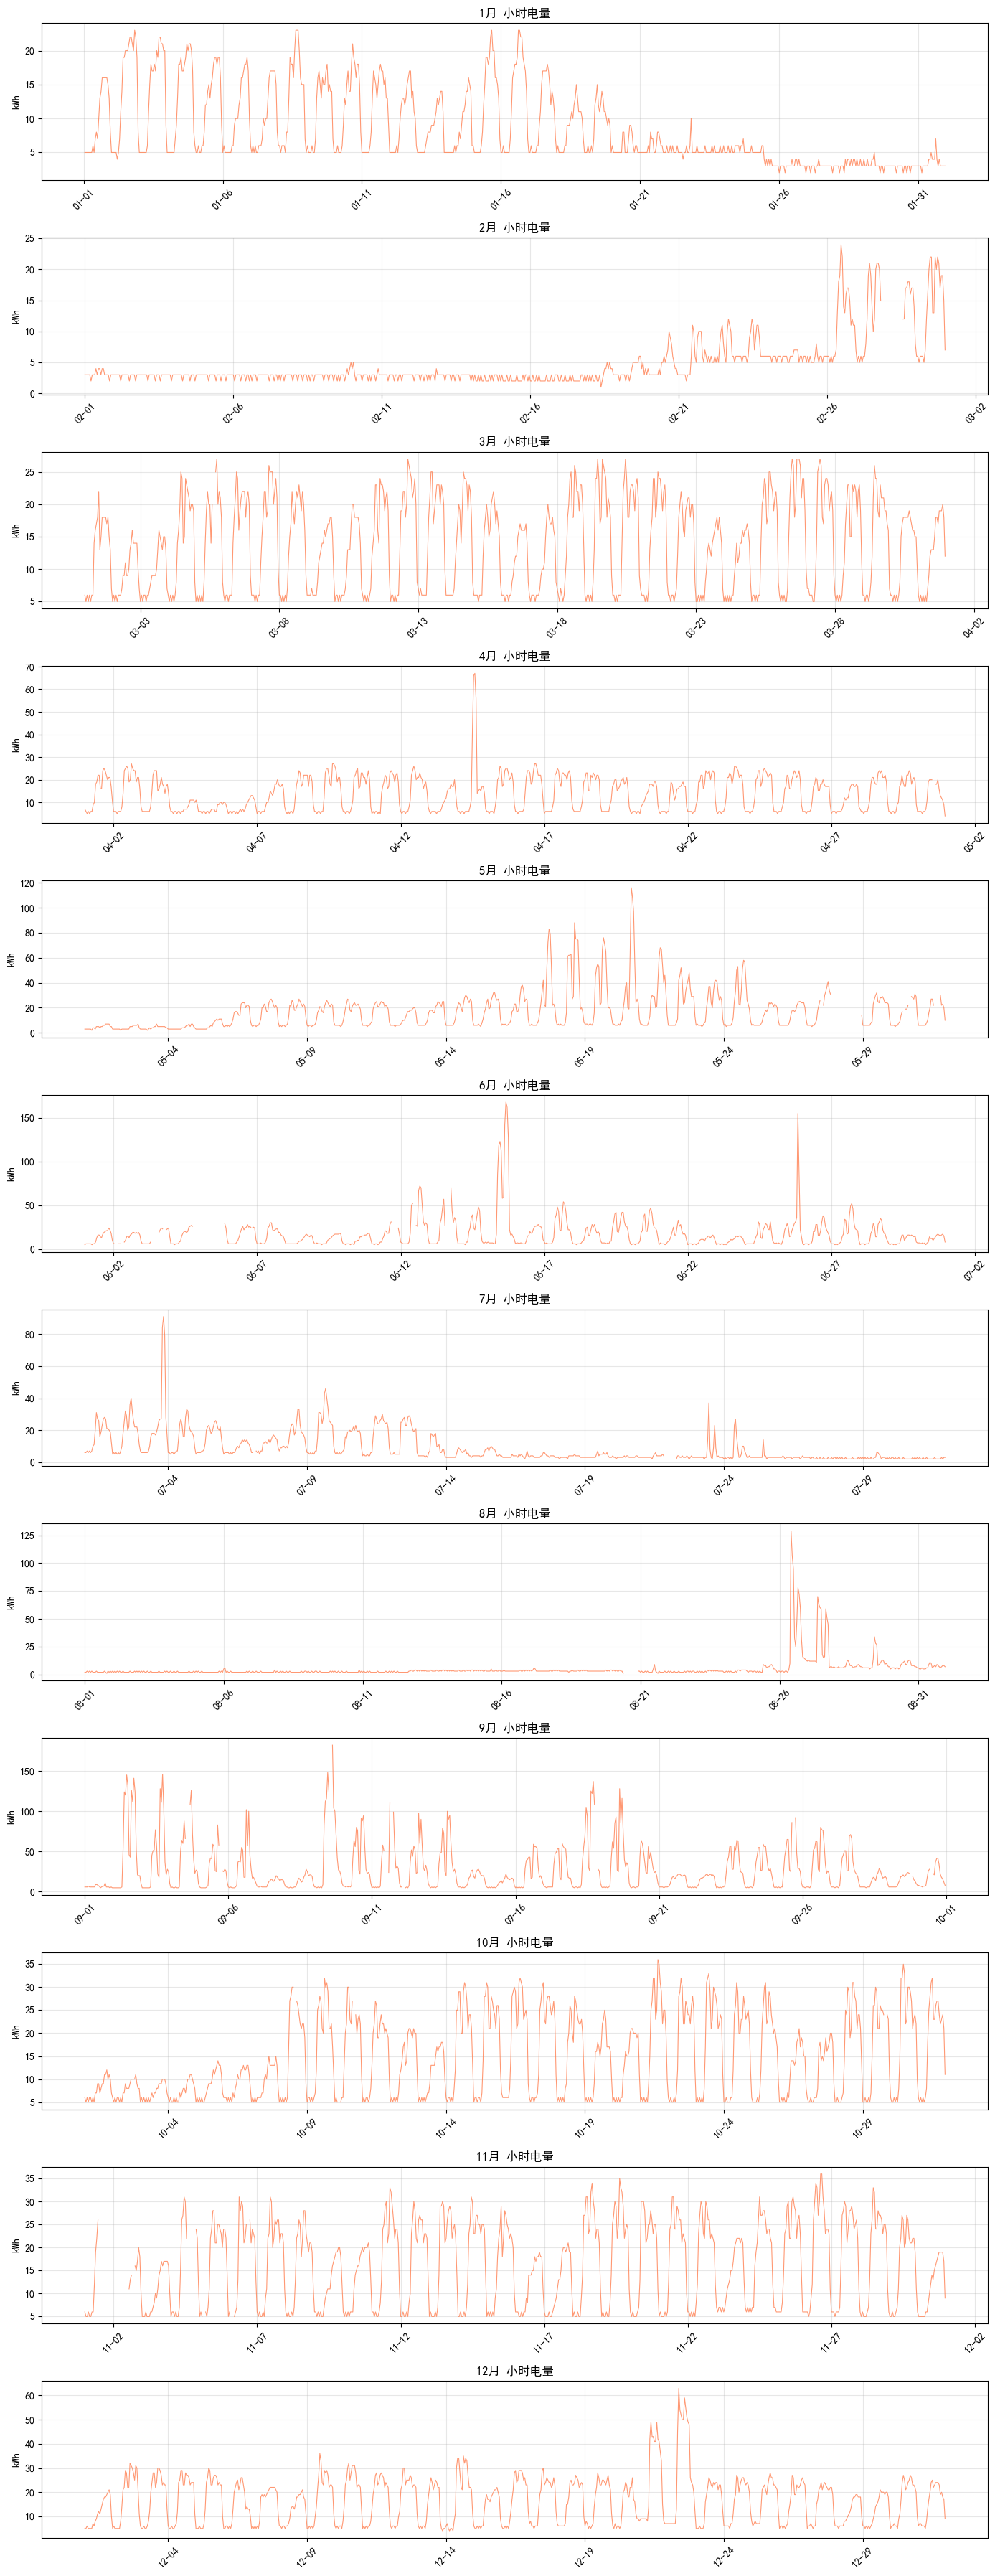

In [6]:
df_load['month'] = df_load.index.month
months = df_load['month'].unique()
n_months = len(months)

fig, axes = plt.subplots(n_months, 1, figsize=(14, 3*n_months), sharex=False)

for i, month in enumerate(sorted(months)):
    month_data = df_load[df_load['month'] == month]
    axes[i].plot(month_data.index, month_data['hourly_kwh'], 
                 color='coral', linewidth=0.8, alpha=0.8)
    axes[i].set_title(f'{month}月 小时电量')
    axes[i].set_ylabel('kWh')
    axes[i].grid(True, alpha=0.3)
    
    axes[i].xaxis.set_major_locator(mdates.DayLocator(interval=5))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

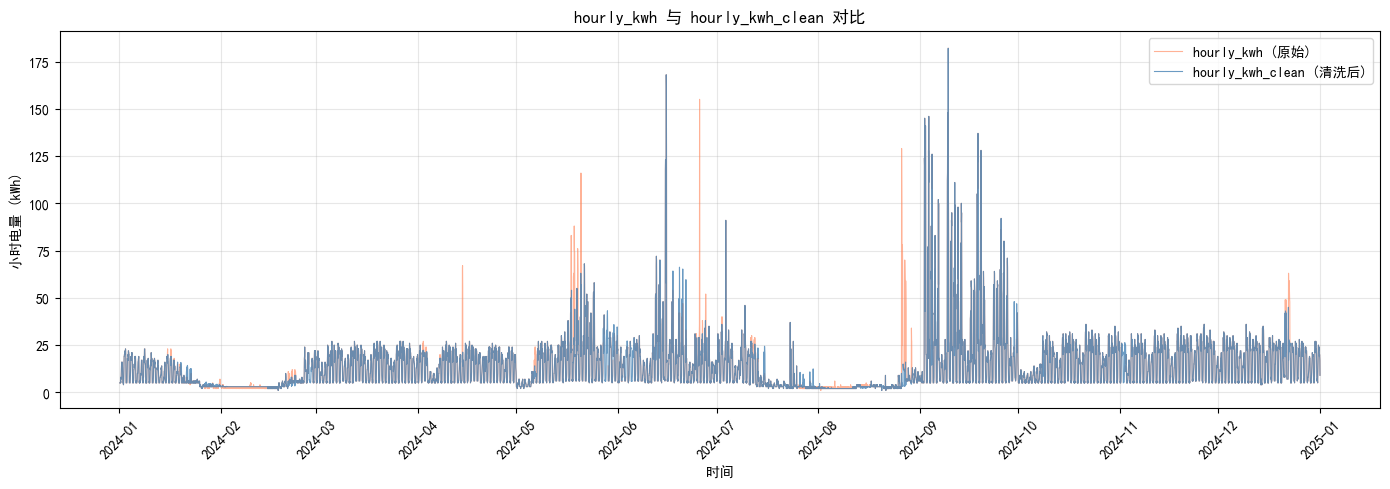

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_load.index, df_load['hourly_kwh'], color='coral', linewidth=0.8, alpha=0.6, label='hourly_kwh (原始)')
ax.plot(df_load.index, df_load['hourly_kwh_clean'], color='steelblue', linewidth=0.8, alpha=0.8, label='hourly_kwh_clean (清洗后)')
ax.set_xlabel('时间')
ax.set_ylabel('小时电量 (kWh)')
ax.set_title('hourly_kwh 与 hourly_kwh_clean 对比')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

---
## 二、目标负荷数据可视化

In [8]:
# 加载目标负荷数据
df_target = pd.read_csv('data/目标负荷_预处理后.csv', parse_dates=['timestamp'])
df_target.set_index('timestamp', inplace=True)

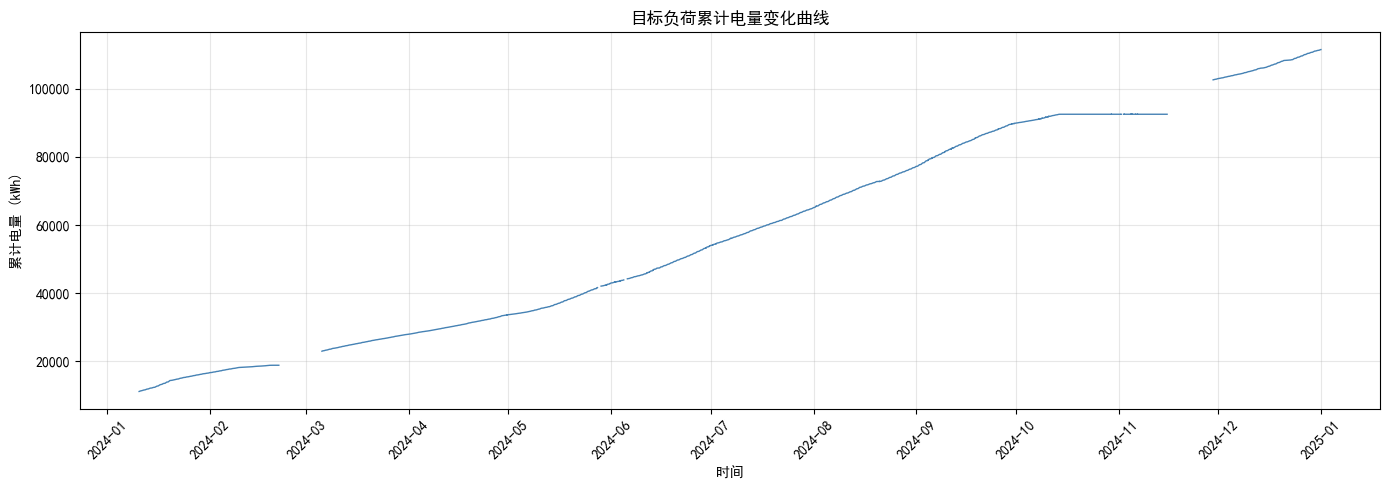

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_target.index, df_target['load_kwh'], color='steelblue', linewidth=1)
ax.set_xlabel('时间')
ax.set_ylabel('累计电量 (kWh)')
ax.set_title('目标负荷累计电量变化曲线')
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

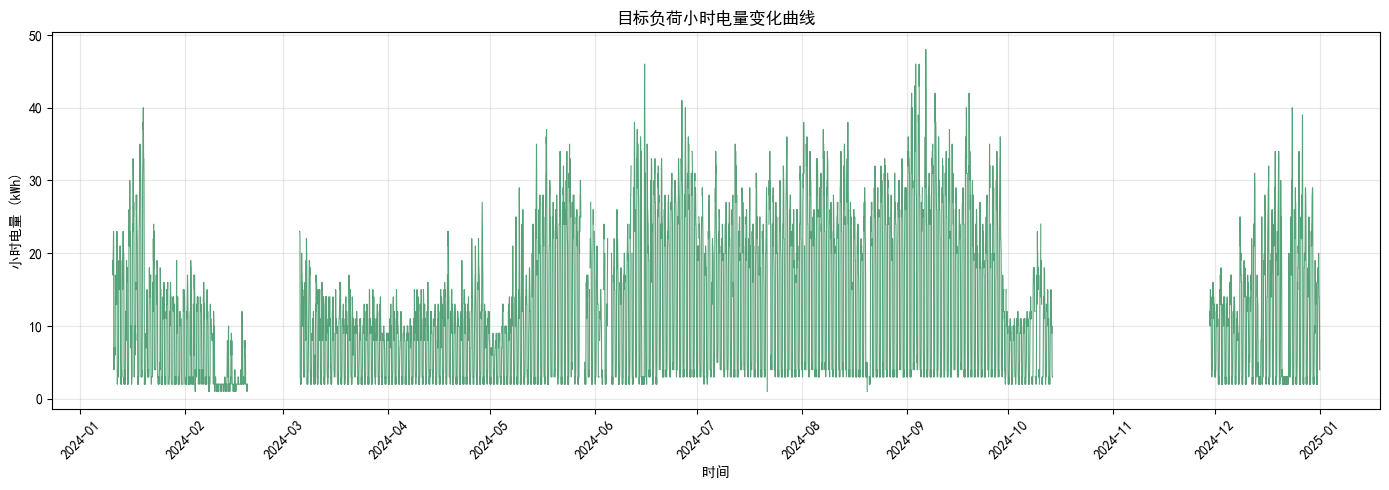

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_target.index, df_target['hourly_kwh'], color='seagreen', linewidth=0.8, alpha=0.8)
ax.set_xlabel('时间')
ax.set_ylabel('小时电量 (kWh)')
ax.set_title('目标负荷小时电量变化曲线')
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

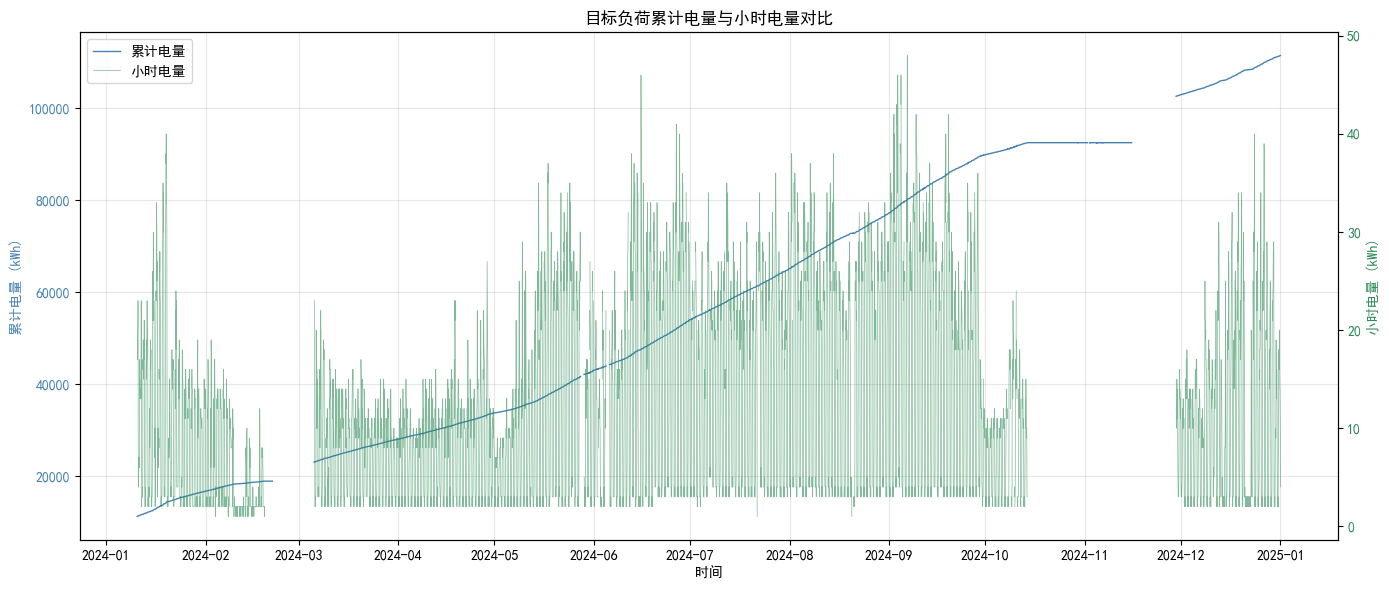

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# 累计电量（左Y轴）
color1 = 'steelblue'
ax1.plot(df_target.index, df_target['load_kwh'], color=color1, linewidth=1, label='累计电量')
ax1.set_xlabel('时间')
ax1.set_ylabel('累计电量 (kWh)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# 小时电量（右Y轴）
ax2 = ax1.twinx()
color2 = 'seagreen'
ax2.plot(df_target.index, df_target['hourly_kwh'], color=color2, linewidth=0.5, alpha=0.6, label='小时电量')
ax2.set_ylabel('小时电量 (kWh)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('目标负荷累计电量与小时电量对比')
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

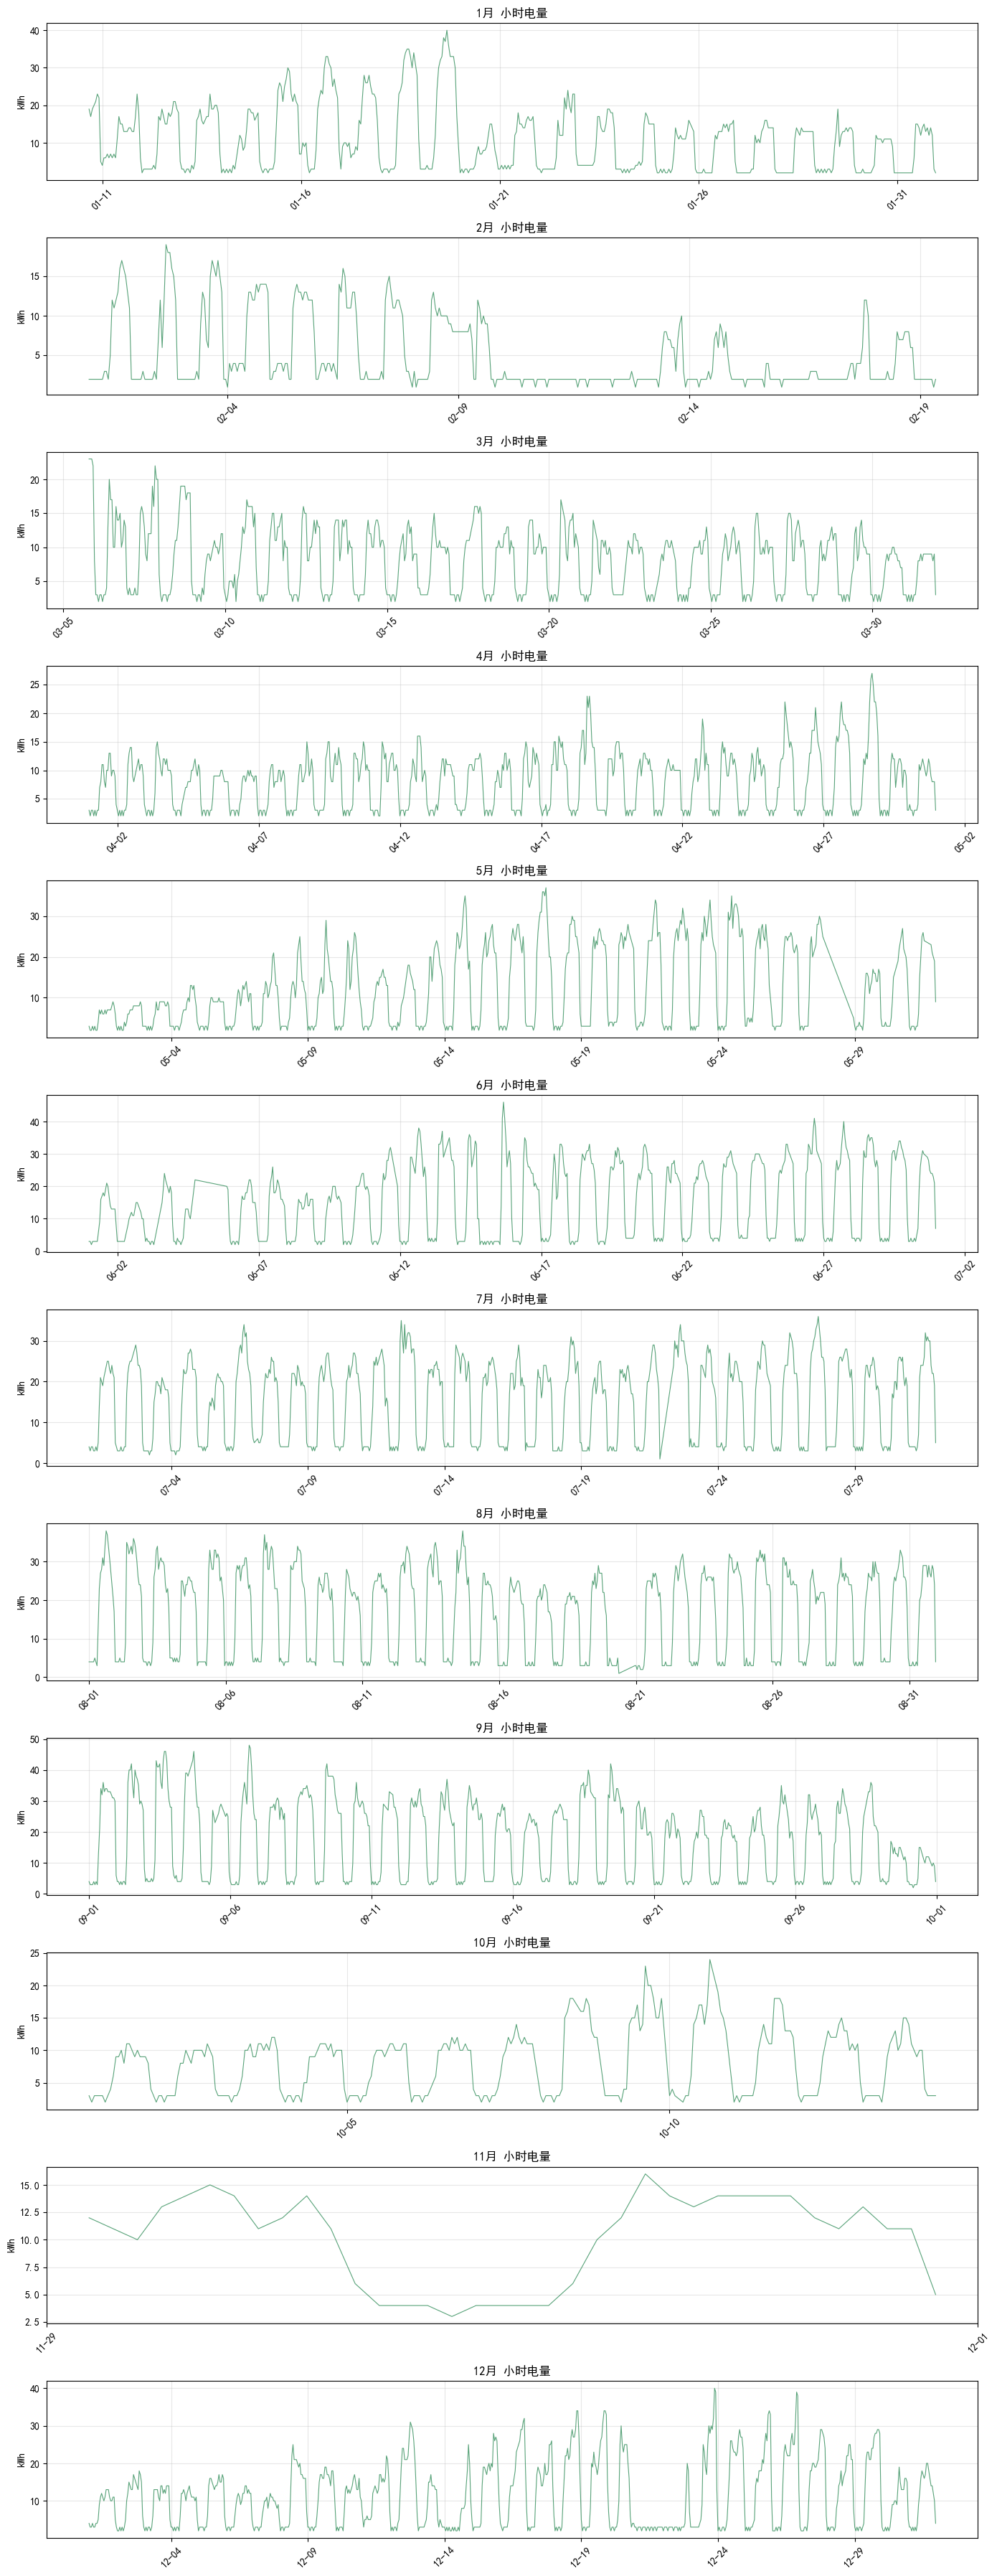

In [12]:
# 只取有效数据
valid_df = df_target.dropna(subset=['hourly_kwh'])
valid_df = valid_df.copy()
valid_df['month'] = valid_df.index.month

months = sorted(valid_df['month'].unique())
n_months = len(months)

fig, axes = plt.subplots(n_months, 1, figsize=(14, 3*n_months), sharex=False)

if n_months == 1:
    axes = [axes]

for i, month in enumerate(months):
    month_data = valid_df[valid_df['month'] == month]
    axes[i].plot(month_data.index, month_data['hourly_kwh'], 
                 color='seagreen', linewidth=0.8, alpha=0.8)
    axes[i].set_title(f'{month}月 小时电量')
    axes[i].set_ylabel('kWh')
    axes[i].grid(True, alpha=0.3)
    
    axes[i].xaxis.set_major_locator(mdates.DayLocator(interval=5))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

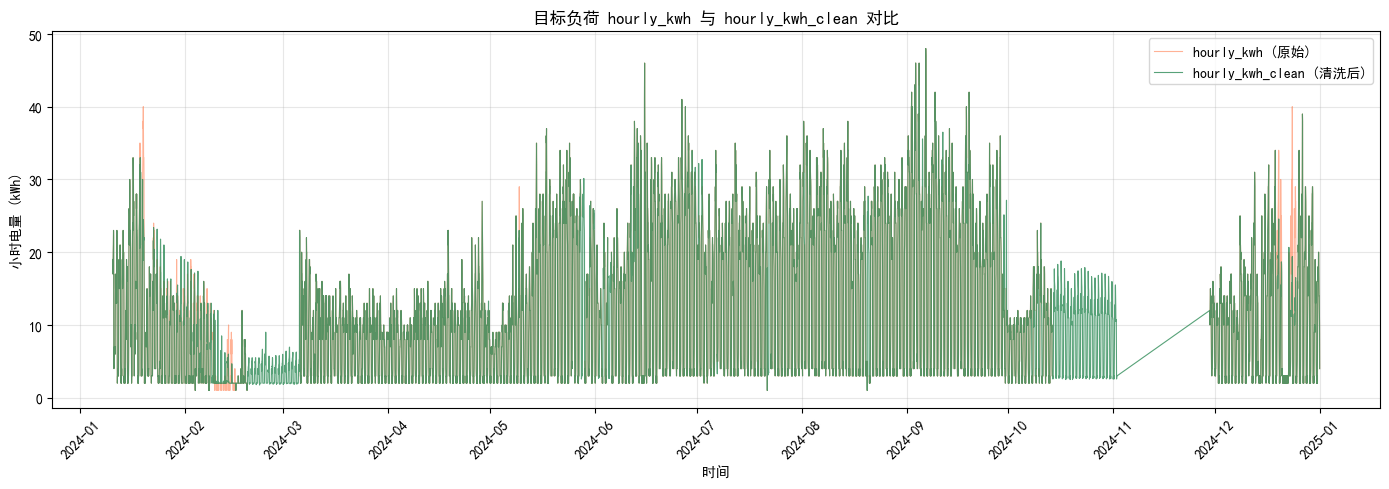

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_target.index, df_target['hourly_kwh'], color='coral', linewidth=0.8, alpha=0.6, label='hourly_kwh (原始)')
ax.plot(df_target.index, df_target['hourly_kwh_clean'], color='seagreen', linewidth=0.8, alpha=0.8, label='hourly_kwh_clean (清洗后)')
ax.set_xlabel('时间')
ax.set_ylabel('小时电量 (kWh)')
ax.set_title('目标负荷 hourly_kwh 与 hourly_kwh_clean 对比')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

---
## 三、特征相关性分析

In [14]:
# 加载特征数据
df_features = pd.read_csv('data/负荷_天气_时间特征.csv', parse_dates=['timestamp'])
df_features.set_index('timestamp', inplace=True)

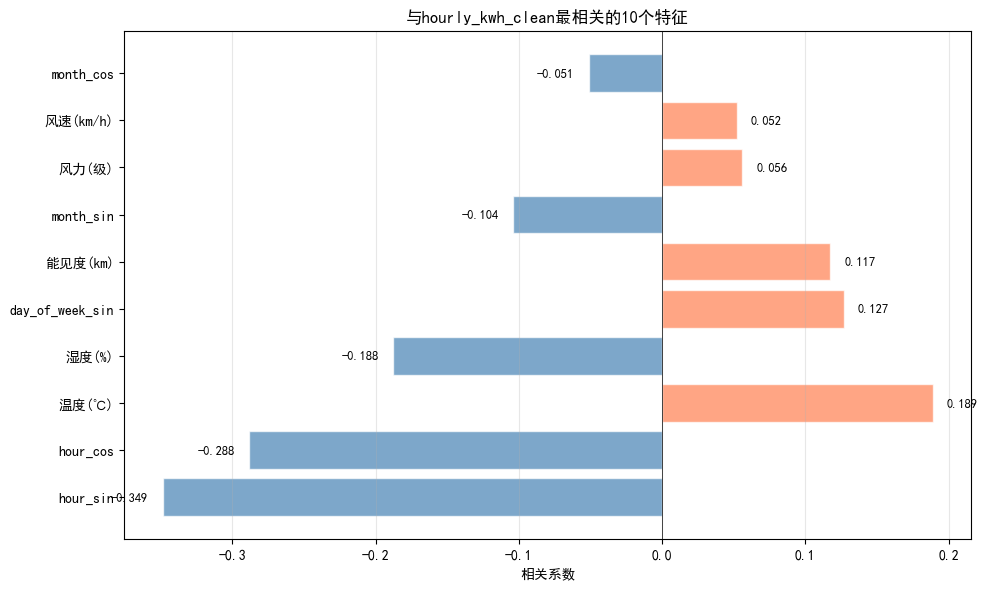

In [15]:
# 获取所有数值列
all_features = df_features.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['month', 'hour', 'temp_bin']
all_features = [col for col in all_features if col not in exclude_cols]

# 计算与hourly_kwh_clean的相关系数
target_corr = df_features[all_features].corr()['hourly_kwh_clean'].drop('hourly_kwh_clean')
target_corr = target_corr.sort_values(key=abs, ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))

# 根据正负相关性着色
colors = ['coral' if x > 0 else 'steelblue' for x in target_corr.values]
bars = ax.barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.7, edgecolor='white')

ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index)
ax.set_xlabel('相关系数')
ax.set_title('与hourly_kwh_clean最相关的10个特征')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars, target_corr.values)):
    ax.text(val + 0.01 if val > 0 else val - 0.01, i, f'{val:.3f}', 
            va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()